In [1]:
import pandas as pd

df = pd.read_parquet('../data/raw/yellow_tripdata_2025-10.parquet')

In [2]:
df.shape

(4428699, 20)

In [3]:
df.sample(3)

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
4292189,2,2025-10-28 18:15:50,2025-10-28 19:08:06,NaN,0.00,NaN,None,231,42,0,11.48,0.00,0.5,0.0,0.0,1.0,16.23,NaN,NaN,0.75
790475,1,2025-10-08 15:33:13,2025-10-08 15:48:16,4.0,1.40,1.0,N,237,163,1,13.50,3.25,0.5,0.0,0.0,1.0,18.25,2.5,0.0,0.75
3924738,2,2025-10-16 20:40:35,2025-10-16 21:09:24,NaN,5.48,NaN,None,68,42,0,-4.75,0.00,0.5,0.0,0.0,1.0,5.13,NaN,NaN,0.75


In [4]:
df.isna().sum()

VendorID                      0
tpep_pickup_datetime          0
tpep_dropoff_datetime         0
passenger_count          990887
trip_distance                 0
RatecodeID               990887
store_and_fwd_flag       990887
PULocationID                  0
DOLocationID                  0
payment_type                  0
fare_amount                   0
extra                         0
mta_tax                       0
tip_amount                    0
tolls_amount                  0
improvement_surcharge         0
total_amount                  0
congestion_surcharge     990887
Airport_fee              990887
cbd_congestion_fee            0
dtype: int64

In [5]:
# ЧАСТЬ 1: ПРОПУСКИ И ДУБЛИКАТЫ
# строки с хотя бы одним NaN — это ровно те же строки, где payment_type == 0

df.index[df.isna().any(axis=1)].equals(df.index[df["payment_type"] == 0])

True

In [6]:
df[df.duplicated()].shape

(0, 20)

In [7]:
# ЧАСТЬ 2: МИНИМАЛЬНАЯ ОЧИСТКА ДАННЫХ
mask_1 = df["tpep_pickup_datetime"] > df["tpep_dropoff_datetime"]
mask_2 = (df["tpep_pickup_datetime"] == df["tpep_dropoff_datetime"]) & (df['trip_distance'] != 0)
mask_3 = (df["tpep_pickup_datetime"] < '2025-10-01') | (df["tpep_pickup_datetime"] >= '2025-11-01')
df[mask_1 | mask_2 | mask_3]

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
1,7,2025-10-01 00:00:08,2025-10-01 00:00:08,1.0,5.00,1.0,N,107,225,1,28.20,0.0,0.5,8.49,0.0,1.0,42.44,2.5,0.0,0.75
121,7,2025-10-01 00:03:04,2025-10-01 00:03:04,1.0,1.04,1.0,N,246,164,1,9.30,0.0,0.5,3.01,0.0,1.0,18.06,2.5,0.0,0.75
122,7,2025-10-01 00:24:56,2025-10-01 00:24:56,1.0,2.32,1.0,N,162,262,1,14.20,0.0,0.5,3.99,0.0,1.0,23.94,2.5,0.0,0.75
206,7,2025-10-01 00:07:16,2025-10-01 00:07:16,1.0,3.00,1.0,N,113,142,1,18.40,0.0,0.5,33.17,0.0,1.0,57.32,2.5,0.0,0.75
207,7,2025-10-01 00:12:58,2025-10-01 00:12:58,1.0,0.86,1.0,N,48,48,1,5.80,0.0,0.5,2.31,0.0,1.0,13.86,2.5,0.0,0.75
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4085510,2,2025-10-21 22:22:00,2025-10-21 22:22:00,NaN,0.01,NaN,None,161,161,0,-7.64,0.0,0.5,0.00,0.0,1.0,-2.89,NaN,NaN,0.75
4116668,2,2025-10-23 01:12:00,2025-10-23 01:12:00,NaN,0.02,NaN,None,161,161,0,-4.36,0.0,0.5,0.00,0.0,1.0,0.39,NaN,NaN,0.75
4193070,2,2025-10-25 04:26:00,2025-10-25 04:26:00,NaN,0.05,NaN,None,107,137,0,-3.59,0.0,0.5,0.00,0.0,1.0,1.16,NaN,NaN,0.75
4316559,2,2025-10-29 18:34:59,2025-10-29 18:34:59,NaN,7.65,NaN,None,17,17,0,9.14,0.0,0.5,0.00,0.0,1.0,13.89,NaN,NaN,0.75


In [8]:
# проблемных строк 66648
# 66648 записей составляют ~1.5% от размера всей выборки, удалим эти записи
df = df[~(mask_1 | mask_2 | mask_3)]

In [9]:
# проверяю PULocationID, DOLocationID
zones = pd.read_csv("../data/raw/taxi_zone_lookup.csv")
valid_ids = set(zones["LocationID"])
print('записей с несуществующими зонами посадки:', df[~(df["PULocationID"].isin(valid_ids))].shape[0])
print('записей с несуществующими зонами высадки:', df[~(df["DOLocationID"].isin(valid_ids))].shape[0])

записей с несуществующими зонами посадки: 0
записей с несуществующими зонами высадки: 0


In [10]:
df[df["PULocationID"] == 264]

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
403,1,2025-10-01 00:24:14,2025-10-01 00:36:16,1.0,1.70,1.0,N,264,264,1,12.80,4.25,0.5,5.55,0.00,1.0,24.10,2.5,0.0,0.75
1731,2,2025-10-01 01:20:36,2025-10-01 01:40:45,1.0,5.90,1.0,N,264,264,2,27.50,1.00,0.5,0.00,0.00,1.0,30.00,0.0,0.0,0.00
3904,2,2025-10-01 06:45:00,2025-10-01 06:57:15,1.0,2.76,1.0,N,264,234,1,14.90,0.00,0.5,4.91,0.00,1.0,24.56,2.5,0.0,0.75
4376,2,2025-10-01 06:05:07,2025-10-01 06:10:25,1.0,0.99,1.0,N,264,50,1,7.20,0.00,0.5,1.79,0.00,1.0,13.74,2.5,0.0,0.75
5682,1,2025-10-01 07:08:21,2025-10-01 07:46:45,1.0,11.90,1.0,N,264,161,1,53.40,3.25,0.5,10.00,6.94,1.0,75.09,2.5,0.0,0.75
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4394202,2,2025-10-31 10:30:01,2025-10-31 10:41:27,NaN,2.11,NaN,None,264,193,0,23.76,0.00,0.5,3.22,6.94,1.0,35.42,NaN,NaN,0.00
4400411,1,2025-10-31 15:55:47,2025-10-31 16:29:54,NaN,3.10,NaN,None,264,88,0,28.90,0.00,0.5,6.73,0.00,1.0,40.38,NaN,NaN,0.75
4404426,2,2025-10-31 17:50:34,2025-10-31 18:04:08,NaN,1.41,NaN,None,264,264,0,2.95,0.00,0.5,0.00,0.00,1.0,4.45,NaN,NaN,0.00
4415714,2,2025-10-31 20:24:12,2025-10-31 20:47:18,NaN,0.00,NaN,None,264,264,0,4.84,0.00,0.5,0.00,0.00,1.0,8.52,NaN,NaN,0.00


In [11]:
# записей с зоной 264 всего 6587
# Для анализа локального спроса нужна известная зона посадки, поэтому удаляю их.
df = df[df["PULocationID"] != 264]

In [12]:
# ЧАСТЬ 3: EDA
print('удалено записей из таблицы:', 4428699-df.shape[0])
print('осталось записей о поездке:', df.shape[0])
print('максимальная и минимальная даты в таблице:', df['tpep_pickup_datetime'].max(), df['tpep_pickup_datetime'].min())

удалено записей из таблицы: 73235
осталось записей о поездке: 4355464
максимальная и минимальная даты в таблице: 2025-10-31 23:59:59 2025-10-01 00:00:00


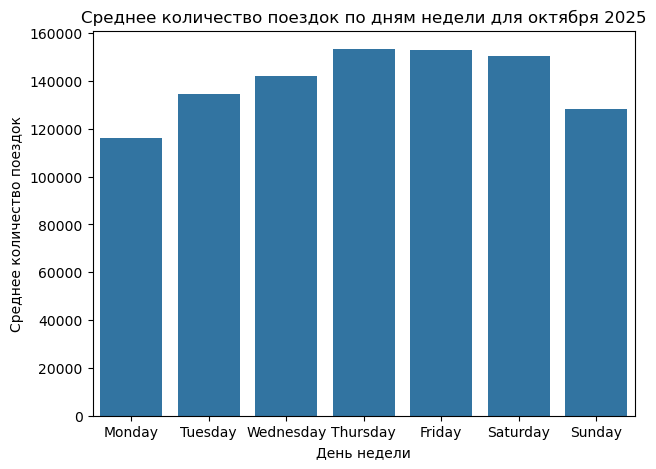

In [13]:
# рассмотрим распределение записей по дням недели (считая для начала поездки) и визуализируем
import seaborn as sns
import matplotlib.pyplot as plt


plt.figure(figsize=(7, 5))
first_group = df.groupby(df['tpep_pickup_datetime'].dt.date).size()
weekday_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]
second_group = first_group.groupby(pd.to_datetime(first_group.index).day_name()).mean()
second_group = second_group.reindex(weekday_order)
sns.barplot(data=second_group).set(title='Среднее количество поездок по дням недели для октября 2025',
                                   xlabel='День недели',
                                   ylabel='Среднее количество поездок');

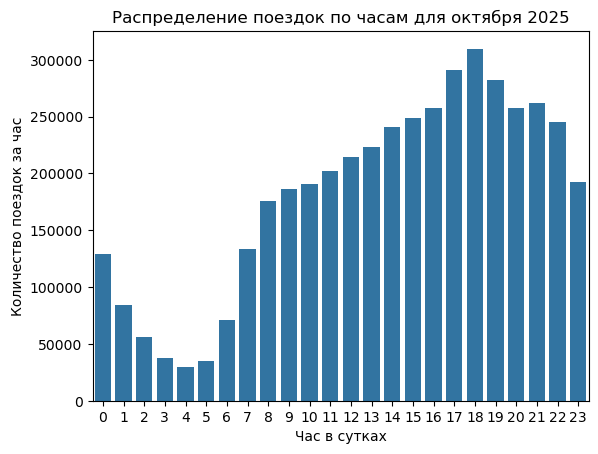

In [14]:
# рассмотрим распределение записей по часам и визуализируем
gr = df.groupby(df['tpep_pickup_datetime'].dt.hour).size()
sns.barplot(data=gr).set(
    title='Распределение поездок по часам для октября 2025', 
    xlabel='Час в сутках', 
    ylabel='Количество поездок за час');

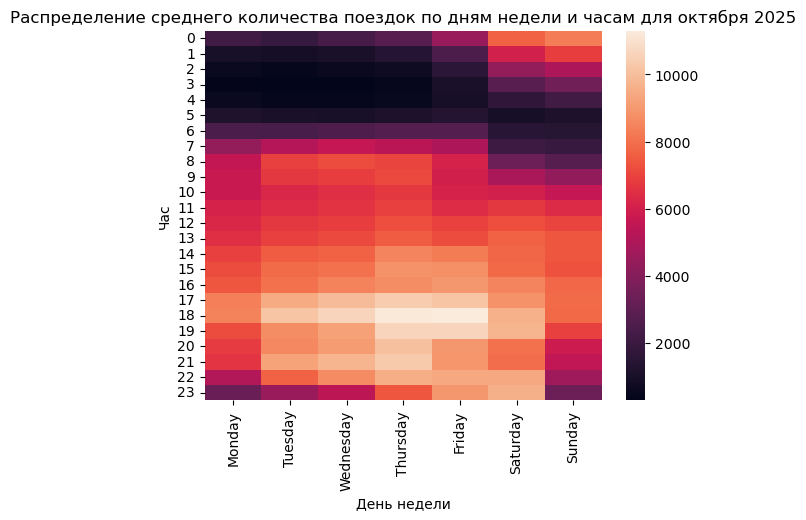

In [15]:
# Посмотрим среднее количество поездок по дню недели и часу
day_hour = df.groupby([
    df["tpep_pickup_datetime"].dt.date.rename("date"), 
    df["tpep_pickup_datetime"].dt.day_name().rename("day_of_week"), 
    df["tpep_pickup_datetime"].dt.hour.rename("hour")]).size().rename("trips")
day_hour = day_hour.reset_index()

day_hour = day_hour.groupby([
    day_hour["day_of_week"],
    day_hour["hour"]])["trips"].mean()
day_hour = day_hour.reset_index()


day_hour = day_hour.pivot(columns="day_of_week", index="hour", values="trips")
day_hour = day_hour[weekday_order]

sns.heatmap(day_hour).set(title="Распределение среднего количества поездок по дням недели и часам для октября 2025", 
                          xlabel="День недели", 
                          ylabel="Час");

In [16]:
# Графики распределений не имеют значимых отличий от сентябрьских.

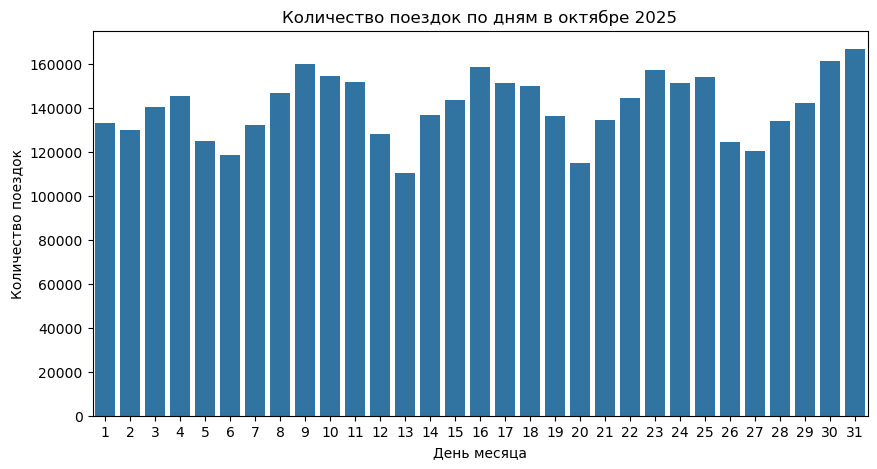

In [17]:
# Рассмотрим спрос на такси в конкретные даты

from datetime import date


gr_date = df.groupby(df["tpep_pickup_datetime"].dt.date.rename("date")).size().rename("trips")
gr_date = gr_date.to_frame()

gr_date = gr_date.reset_index()
gr_date["date"] = pd.to_datetime(gr_date["date"])
gr_date["date"] = gr_date["date"].dt.day

plt.figure(figsize=(10, 5))
sns.barplot(data=gr_date, x="date", y="trips").set(
    title="Количество поездок по дням в октябре 2025", 
    xlabel="День месяца", 
    ylabel="Количество поездок");

# Недельная цикличность сохраняется.
# Особенно низкие значения наблюдаются по понедельникам: 6, 13, 20, 27 октября.

In [18]:
# Зона посадки PULocationID

start_zone_borough = df.groupby(df["PULocationID"]).size().rename("trips")
start_zone_borough = start_zone_borough.to_frame()
start_zone_borough = start_zone_borough.merge(zones[["LocationID", "Borough", "Zone"]], left_index=True, right_on='LocationID')
start_zone_borough = start_zone_borough.set_index("LocationID")
start_borough = start_zone_borough.groupby(start_zone_borough["Borough"])["trips"].sum().sort_values()
start_borough = start_borough.to_frame()
start_borough
# ожидаемо, поездки на жёлтых такси всё так же преобладают на Манхэттене

,trips
Borough,
Staten Island,409
EWR,596
Bronx,32471
Brooklyn,152181
Queens,412134
Manhattan,3755735


In [19]:
# ЧАСТЬ 4: ИСКОМЫЕ ДАННЫЕ
venue_zone_ids = [79, 161, 163, 186, 239]

df_selected = df[
    df["PULocationID"].isin(venue_zone_ids)
]

data_pickup = (
    df_selected
    .groupby([
        df_selected["tpep_pickup_datetime"].dt.floor("D").rename("date"),
        df_selected["tpep_pickup_datetime"].dt.hour.rename("hour"),
        df_selected["PULocationID"].rename("LocationID")
    ])
    .size()
    .rename("pickups")
    .reset_index()
)

data_pickup

,date,hour,LocationID,pickups
0,2025-10-01,0,79,102
1,2025-10-01,0,161,94
2,2025-10-01,0,163,49
3,2025-10-01,0,186,42
4,2025-10-01,0,239,27
...,...,...,...,...
3712,2025-10-31,23,79,633
3713,2025-10-31,23,161,166
3714,2025-10-31,23,163,173
3715,2025-10-31,23,186,145


In [20]:
# В таблице должно быть 31 день x 24 часа x 5 зон = 3720 записей, сейчас в таблице 3717 записей.

full_index = pd.MultiIndex.from_product(
    [
        pd.date_range("2025-10-01", "2025-10-31", freq="D"),
        range(24),
        venue_zone_ids
    ],
    names=["date", "hour", "LocationID"]
)

data_pickup = (
    data_pickup
    .set_index(["date", "hour", "LocationID"])
    .reindex(full_index, fill_value=0)
    .reset_index()
)

assert (
    data_pickup["pickups"].sum()
    ==
    df["PULocationID"].isin(venue_zone_ids).sum()
)

data_pickup

,date,hour,LocationID,pickups
0,2025-10-01,0,79,102
1,2025-10-01,0,161,94
2,2025-10-01,0,163,49
3,2025-10-01,0,186,42
4,2025-10-01,0,239,27
...,...,...,...,...
3715,2025-10-31,23,79,633
3716,2025-10-31,23,161,166
3717,2025-10-31,23,163,173
3718,2025-10-31,23,186,145


In [21]:
# ЧАСТЬ 5: СОХРАНЕНИЕ ОБРАБОТАННЫХ ДАННЫХ

from pathlib import Path

processed_taxi_dir = Path("../data/processed/taxi")
processed_taxi_dir.mkdir(parents=True, exist_ok=True)

output_path = (
    processed_taxi_dir
    / "yellow_taxi_pickups_2025_10.parquet"
)

data_pickup.to_parquet(
    output_path,
    index=False
)

In [22]:
data_pickup_check = pd.read_parquet(output_path)

print("Размер:", data_pickup_check.shape)
print(
    "Дубликаты:",
    data_pickup_check.duplicated(
        subset=["date", "hour", "LocationID"]
    ).sum()
)
print("Пропуски:", data_pickup_check.isna().sum().sum())
print("Количество зон:", data_pickup_check["LocationID"].nunique())

assert data_pickup_check.equals(data_pickup)

Размер: (3720, 4)
Дубликаты: 0
Пропуски: 0
Количество зон: 5
